In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


# Read the data, skipping the first 4 header lines
df_met = pd.read_csv(
    "data/HEF30_lf.dat",
    skiprows=4,
    header=None
)

# Optionally, set column names from the second line of the file
with open("data/HEF30_lf.dat", "r") as f:
    lines = f.readlines()
    colnames = [col.strip('"') for col in lines[1].strip().split(",")]

df_met.columns = colnames

In [3]:
# ensure TIMESTAMP is datetime
df_met['TIMESTAMP'] = pd.to_datetime(df_met['TIMESTAMP'])

# compute daily mean as a Series
hef30_daily_hs = (
    df_met
    .resample('D', on='TIMESTAMP')['Snow_Depth']
    .mean()
)

# set index name and series name
hef30_daily_hs.index.name = 'date'
hef30_daily_hs.name       = 'hs'

hef30_daily_hs.to_csv(
    'data/model_input/hef30_daily_hs_input.csv',
    index_label='date'
)

In [4]:
# Convert TIMESTAMP to datetime and set it as index
df_met['TIMESTAMP'] = pd.to_datetime(df_met['TIMESTAMP'])
df_met = df_met.set_index('TIMESTAMP', drop=True)

# Resample to daily frequency (mean of all columns)
daily_mean = df_met.resample('12h').mean()

In [5]:
daily_mean['NetRad'] = (
    daily_mean['SWin_Avg']
  - daily_mean['SWout_Avg']
  + daily_mean['LWin_Avg']
  - daily_mean['LWout_Avg']
)

# Plot mode output

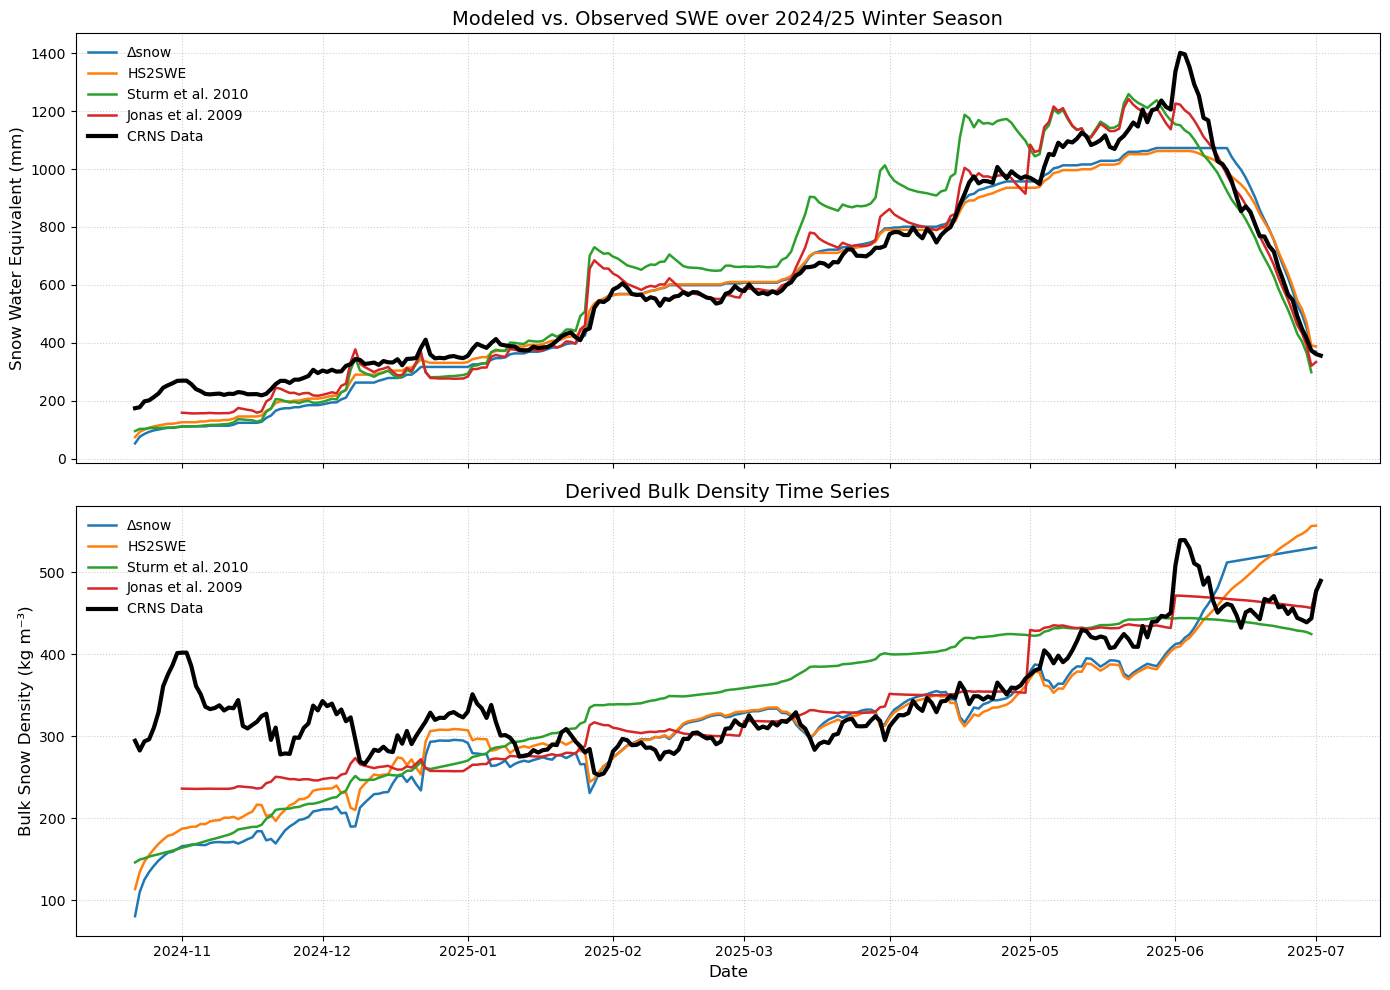

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# ——————————————————————————————————————————————————————————————
# 1) Load your model-output
# ——————————————————————————————————————————————————————————————
df = pd.read_csv(
    "data/output/nixmass_model_output.csv",    
    parse_dates=['date']
)
df.set_index('date', inplace=True)

# remove the first row
df = df[1:]  # Drop row 0 if it’s full of NaNs

# 2) Load your CRNS observations (must have TIMESTAMP, median, density)
CRNS_data = pd.read_csv(
    "data/CRNS_data_processed.csv",            
    parse_dates=['TIMESTAMP']
)
CRNS_data.set_index('TIMESTAMP', inplace=True)

# ——————————————————————————————————————————————————————————————
# 3) Human-readable labels for each modeled SWE time series
# ——————————————————————————————————————————————————————————————
variable_names = {
    'swe_deltasnow': 'Δsnow',
    'swe_hs2swe':    'HS2SWE',
    #'swe_pi16':      'Pistocchi 2016',
    'swe_st10':      'Sturm et al. 2010',
    'swe_jo09':      'Jonas et al. 2009',
}

# ——————————————————————————————————————————————————————————————
# 4) Choose a modern qualitative palette for the models
# ——————————————————————————————————————————————————————————————
palette = plt.get_cmap('tab10')            # 10 distinct colors
model_colors = [palette(i) for i in range(len(variable_names))]

# ——————————————————————————————————————————————————————————————
# 5) Set up figure
# ——————————————————————————————————————————————————————————————
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(14, 10))

# Top: Modeled SWE vs. CRNS SWE
for (key, label), color in zip(variable_names.items(), model_colors):
    ax1.plot(
        df.index,
        df[key],
        label=label,
        lw=1.8,
        color=color
    )

# CRNS observation in bold black
ax1.plot(
    CRNS_data.index,
    CRNS_data['median'],
    label='CRNS Data',
    color='black',
    lw=3,
    zorder=5
)

ax1.set_ylabel('Snow Water Equivalent (mm)', fontsize=12)
ax1.set_title('Modeled vs. Observed SWE over 2024/25 Winter Season', fontsize=14)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(loc='upper left', fontsize=10, frameon=False)

# Bottom: Derived bulk density for each model + CRNS density
for (key, label), color in zip(variable_names.items(), model_colors):
    density_model = df[key] / df['hs']
    ax2.plot(
        df.index,
        density_model,
        label=label ,
        lw=1.8,
        color=color
    )

# CRNS density, bold black
ax2.plot(
    CRNS_data.index,
    CRNS_data['density'],
    label='CRNS Data',
    color='black',
    lw=3,
    zorder=5
)

ax2.set_ylabel('Bulk Snow Density (kg m⁻³)', fontsize=12)
ax2.set_title('Derived Bulk Density Time Series', fontsize=14)
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(loc='upper left', fontsize=10, frameon=False)


plt.savefig("data/output/All_model_SWE_rho.png", dpi=600)

# Final formatting
plt.xlabel('Date', fontsize=12)
plt.tight_layout()
plt.show()


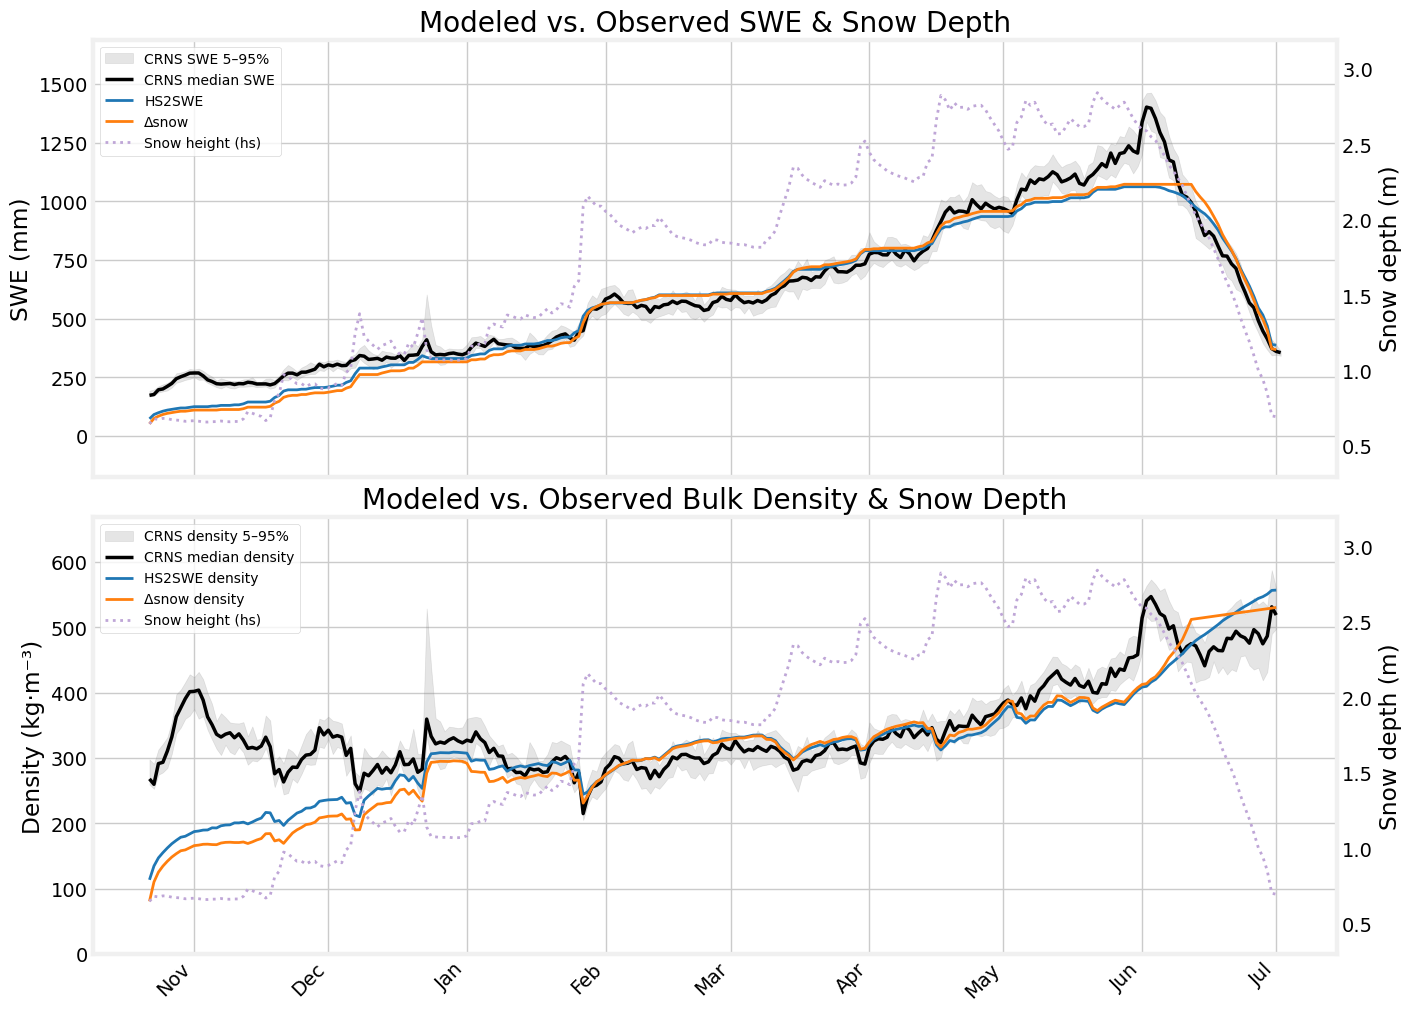

In [18]:
# ——————————————————————————————————————————————————————————————
# 1) Load data and drop first row if needed
# ——————————————————————————————————————————————————————————————
df = (
    pd.read_csv("data/output/nixmass_model_output.csv", parse_dates=['date'])
      .set_index('date')
      .iloc[1:]
)
CRNS = (
    pd.read_csv("data/CRNS_data_processed.csv", parse_dates=['TIMESTAMP'])
      .set_index('TIMESTAMP')
)

# ——————————————————————————————————————————————————————————————
# 2) Define model series
# ——————————————————————————————————————————————————————————————
models = {'swe_hs2swe': 'HS2SWE', 'swe_deltasnow': 'Δsnow'}

# ——————————————————————————————————————————————————————————————
# 3) Compute CRNS-derived density percentiles
# ——————————————————————————————————————————————————————————————
density_p05 = CRNS['p05'] / df['hs']
density_med = CRNS['median'] / df['hs']
density_p95 = CRNS['p95'] / df['hs']


# ——————————————————————————————————————————————————————————————
# 4) Define colors
# ——————————————————————————————————————————————————————————————
model_colors = ['#1f77b4', '#ff7f0e']  # Blue and orange for models
crns_color   = 'k'               # Green for CRNS median
hs_color     = "#bfa6d7"               # Purple for snow depth

# ——————————————————————————————————————————————————————————————
# 5) Plot with improved scaling and colors
# ——————————————————————————————————————————————————————————————
plt.style.use('fivethirtyeight')
fig, (ax_swe, ax_den) = plt.subplots(
    2, 1, sharex=True, figsize=(14, 10), constrained_layout=True
)

# --- Top: SWE + snow depth ---
# CRNS SWE envelope
ax_swe.fill_between(
    CRNS.index, CRNS['p05'], CRNS['p95'],
    color='gray', alpha=0.2, label='CRNS SWE 5–95%'
)
# CRNS median SWE
ax_swe.plot(
    CRNS.index, CRNS['median'],
    color=crns_color, lw=2.5, label='CRNS median SWE'
)
# Model SWE lines
for (col, label), color in zip(models.items(), model_colors):
    ax_swe.plot(
        df.index, df[col],
        color=color, lw=2, label=label
    )

ax_swe.set_title('Modeled vs. Observed SWE & Snow Depth')
ax_swe.set_ylabel('SWE (mm)')

# Secondary y-axis: snow depth
ax_swe2 = ax_swe.twinx()
ax_swe2.plot(
    df.index, df['hs'],
    linestyle=':', lw=2, color=hs_color, label='Snow height (hs)'  # Changed label to 'Snow height (hs)'
)



ax_swe2.set_ylabel('Snow depth (m)')

# --- Bottom: Density + snow depth ---
# CRNS density envelope
ax_den.fill_between(
    CRNS.index, density_p05, density_p95,
    color='gray', alpha=0.2, label='CRNS density 5–95%'
)
# CRNS median density
ax_den.plot(
    CRNS.index, density_med,
    color=crns_color, lw=2.5, label='CRNS median density'
)
# Model density lines
for (col, label), color in zip(models.items(), model_colors):
    ax_den.plot(
        df.index, df[col] / df['hs'],
        color=color, lw=2, label=f'{label} density'
    )

ax_den.set_title('Modeled vs. Observed Bulk Density & Snow Depth')
ax_den.set_ylabel('Density (kg·m⁻³)')

# Secondary y-axis: snow depth
ax_den2 = ax_den.twinx()
ax_den2.plot(
    df.index, df['hs'],
    linestyle=':', lw=2, color=hs_color, label='Snow height (hs)'
)

ax_den2.set_ylabel('Snow depth (m)')





# X-axis formatting
ax_den.xaxis.set_major_locator(mdates.MonthLocator())
ax_den.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
plt.setp(ax_den.get_xticklabels(), rotation=45, ha='right')

# Expand y-limits by 10% margin
for ax in (ax_swe, ax_den, ax_swe2, ax_den2):
    bottom, top = ax.get_ylim()
    margin = (top - bottom) * 0.1
    ax.set_ylim(bottom - margin, top + margin)

ax_swe2.grid(False)
ax_den2.grid(False)


# Save and display with white background
plt.savefig(
    "data/output/hs2swe_dsnow_swe_rho_to_CRNS.png",
    dpi=300,
    facecolor='white',
    edgecolor='white'
)

# Combine legends so each line’s label shows up automatically
from itertools import chain

handles, labels = ax_swe.get_legend_handles_labels()
handles2, labels2 = ax_swe2.get_legend_handles_labels()
ax_swe.legend(handles + handles2, labels + labels2, loc='upper left', fontsize=10, frameon=True)

handles, labels = ax_den.get_legend_handles_labels()
handles2, labels2 = ax_den2.get_legend_handles_labels()
ax_den.legend(handles + handles2, labels + labels2, loc='upper left', fontsize=10, frameon=True)


# Force all backgrounds to white
fig.patch.set_facecolor('white')
for ax in (ax_swe, ax_den, ax_swe2, ax_den2):
    ax.set_facecolor('white')




    # Set tick color to black for contrast
    ax.tick_params(colors='black', which='both')

# Optional: white legend boxes
for ax in (ax_swe, ax_den, ax_swe2, ax_den2):
    leg = ax.get_legend()
    if leg is not None:
        leg.set_frame_on(True)
        leg.get_frame().set_facecolor('white')


# Save figure with white background and visible axes
plt.savefig(
    "data/output/hs2swe_dsnow_swe_rho_to_CRNS.png",
    dpi=300,
    facecolor='white',
    edgecolor='white'
)
plt.show()



# Statistical analysis

In [ ]:
df['SWE_obs'] = CRNS_data['median']

In [ ]:
# Models to compare (you can add/remove columns as needed)
model_cols = ['swe_deltasnow', 'swe_hs2swe', 'swe_pi16', 'swe_st10', 'swe_jo09']
obs_col = 'SWE_obs'

results = []
for col in model_cols:
    # Drop NaNs for fair comparison
    valid = df[[col, obs_col]].dropna()
    M = valid[col]
    O = valid[obs_col]
    
    # Relative Bias
    bias_rel = (M.mean() - O.mean()) / O.mean()
    # RMSE
    rmse = np.sqrt(np.mean((M - O) ** 2))
    # Pearson R
    corr = np.corrcoef(M, O)[0,1]
    
    results.append({
        "Model": col,
        "Relative Bias (%)": 100 * bias_rel,
        "RMSE": rmse,
        "Pearson R": corr
    })

# To DataFrame
summary = pd.DataFrame(results)
summary = summary.set_index("Model")

# Print results
print(summary)


               Relative Bias (%)        RMSE  Pearson R
Model                                                  
swe_deltasnow          -5.502143   80.526498   0.973780
swe_hs2swe             -5.089520   76.667947   0.974630
swe_pi16               -3.933883   80.420506   0.971008
swe_st10                4.527704  117.485367   0.955679
swe_jo09               -0.341961   61.133179   0.984229
